In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set();

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_validate

# Отбор признаков

In [2]:
df = pd.read_csv("https://raw.githubusercontent.com/katarina74/ml_lessons/main/lesson_2/data/techparams_train.csv")
X = df.drop(["target", "index"], axis=1)
y = df[["target"]]

In [3]:
train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.33, random_state=42)

## Корреляционный анализ

In [ ]:
train_X.columns #ghjdthrf fdnjcj[hfytybz]

Index(['back-suspension', 'battery-capacity', 'charge-time', 'compression',
       'consumption-mixed', 'cylinders-order', 'cylinders-value',
       'engine-feeding', 'engine-start', 'engine-stop', 'engine-type',
       'gear-type', 'luxury', 'max-speed', 'power-electro-kw', 'supply-system',
       'valves', 'valvetrain', 'weight', 'configurations_auto-premiere',
       'configurations_back-wheel-base', 'configurations_front-brake',
       'configurations_safety-rating', 'configurations_seats',
       'configurations_tank-volume', 'supergen_year-stop',
       'models_country-from', 'models_group', 'models_light-and-commercial',
       'models_male'],
      dtype='str')

In [5]:
ordinal = ['back-suspension', 'cylinders-order', 'engine-feeding', 'configurations_seats']
numerical = ['battery-capacity', 'charge-time', 'compression', 'consumption-mixed', 'cylinders-value', 'engine-start', 'engine-stop', 'luxury',
             'max-speed', 'power-electro-kw','valves','weight','configurations_auto-premiere','configurations_back-wheel-base','configurations_tank-volume',
             'supergen_year-stop']
catigorial = ['engine-type','gear-type', 'supply-system', 'valvetrain', 'configurations_front-brake', 'configurations_safety-rating','models_country-from',
              'models_group', 'models_light-and-commercial','models_male']

<Axes: xlabel='engine-type', ylabel='Count'>

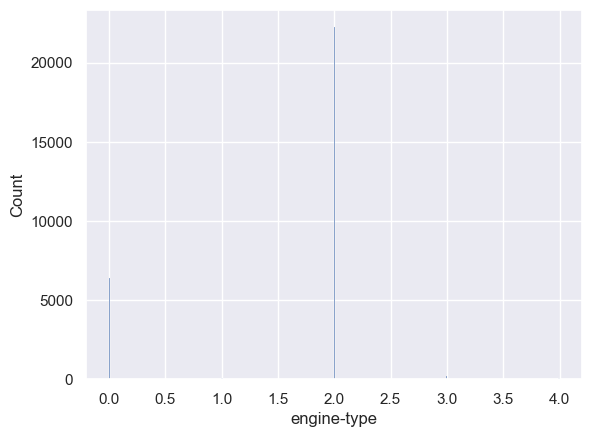

In [6]:
sns.histplot(data=train_X, x='engine-type')

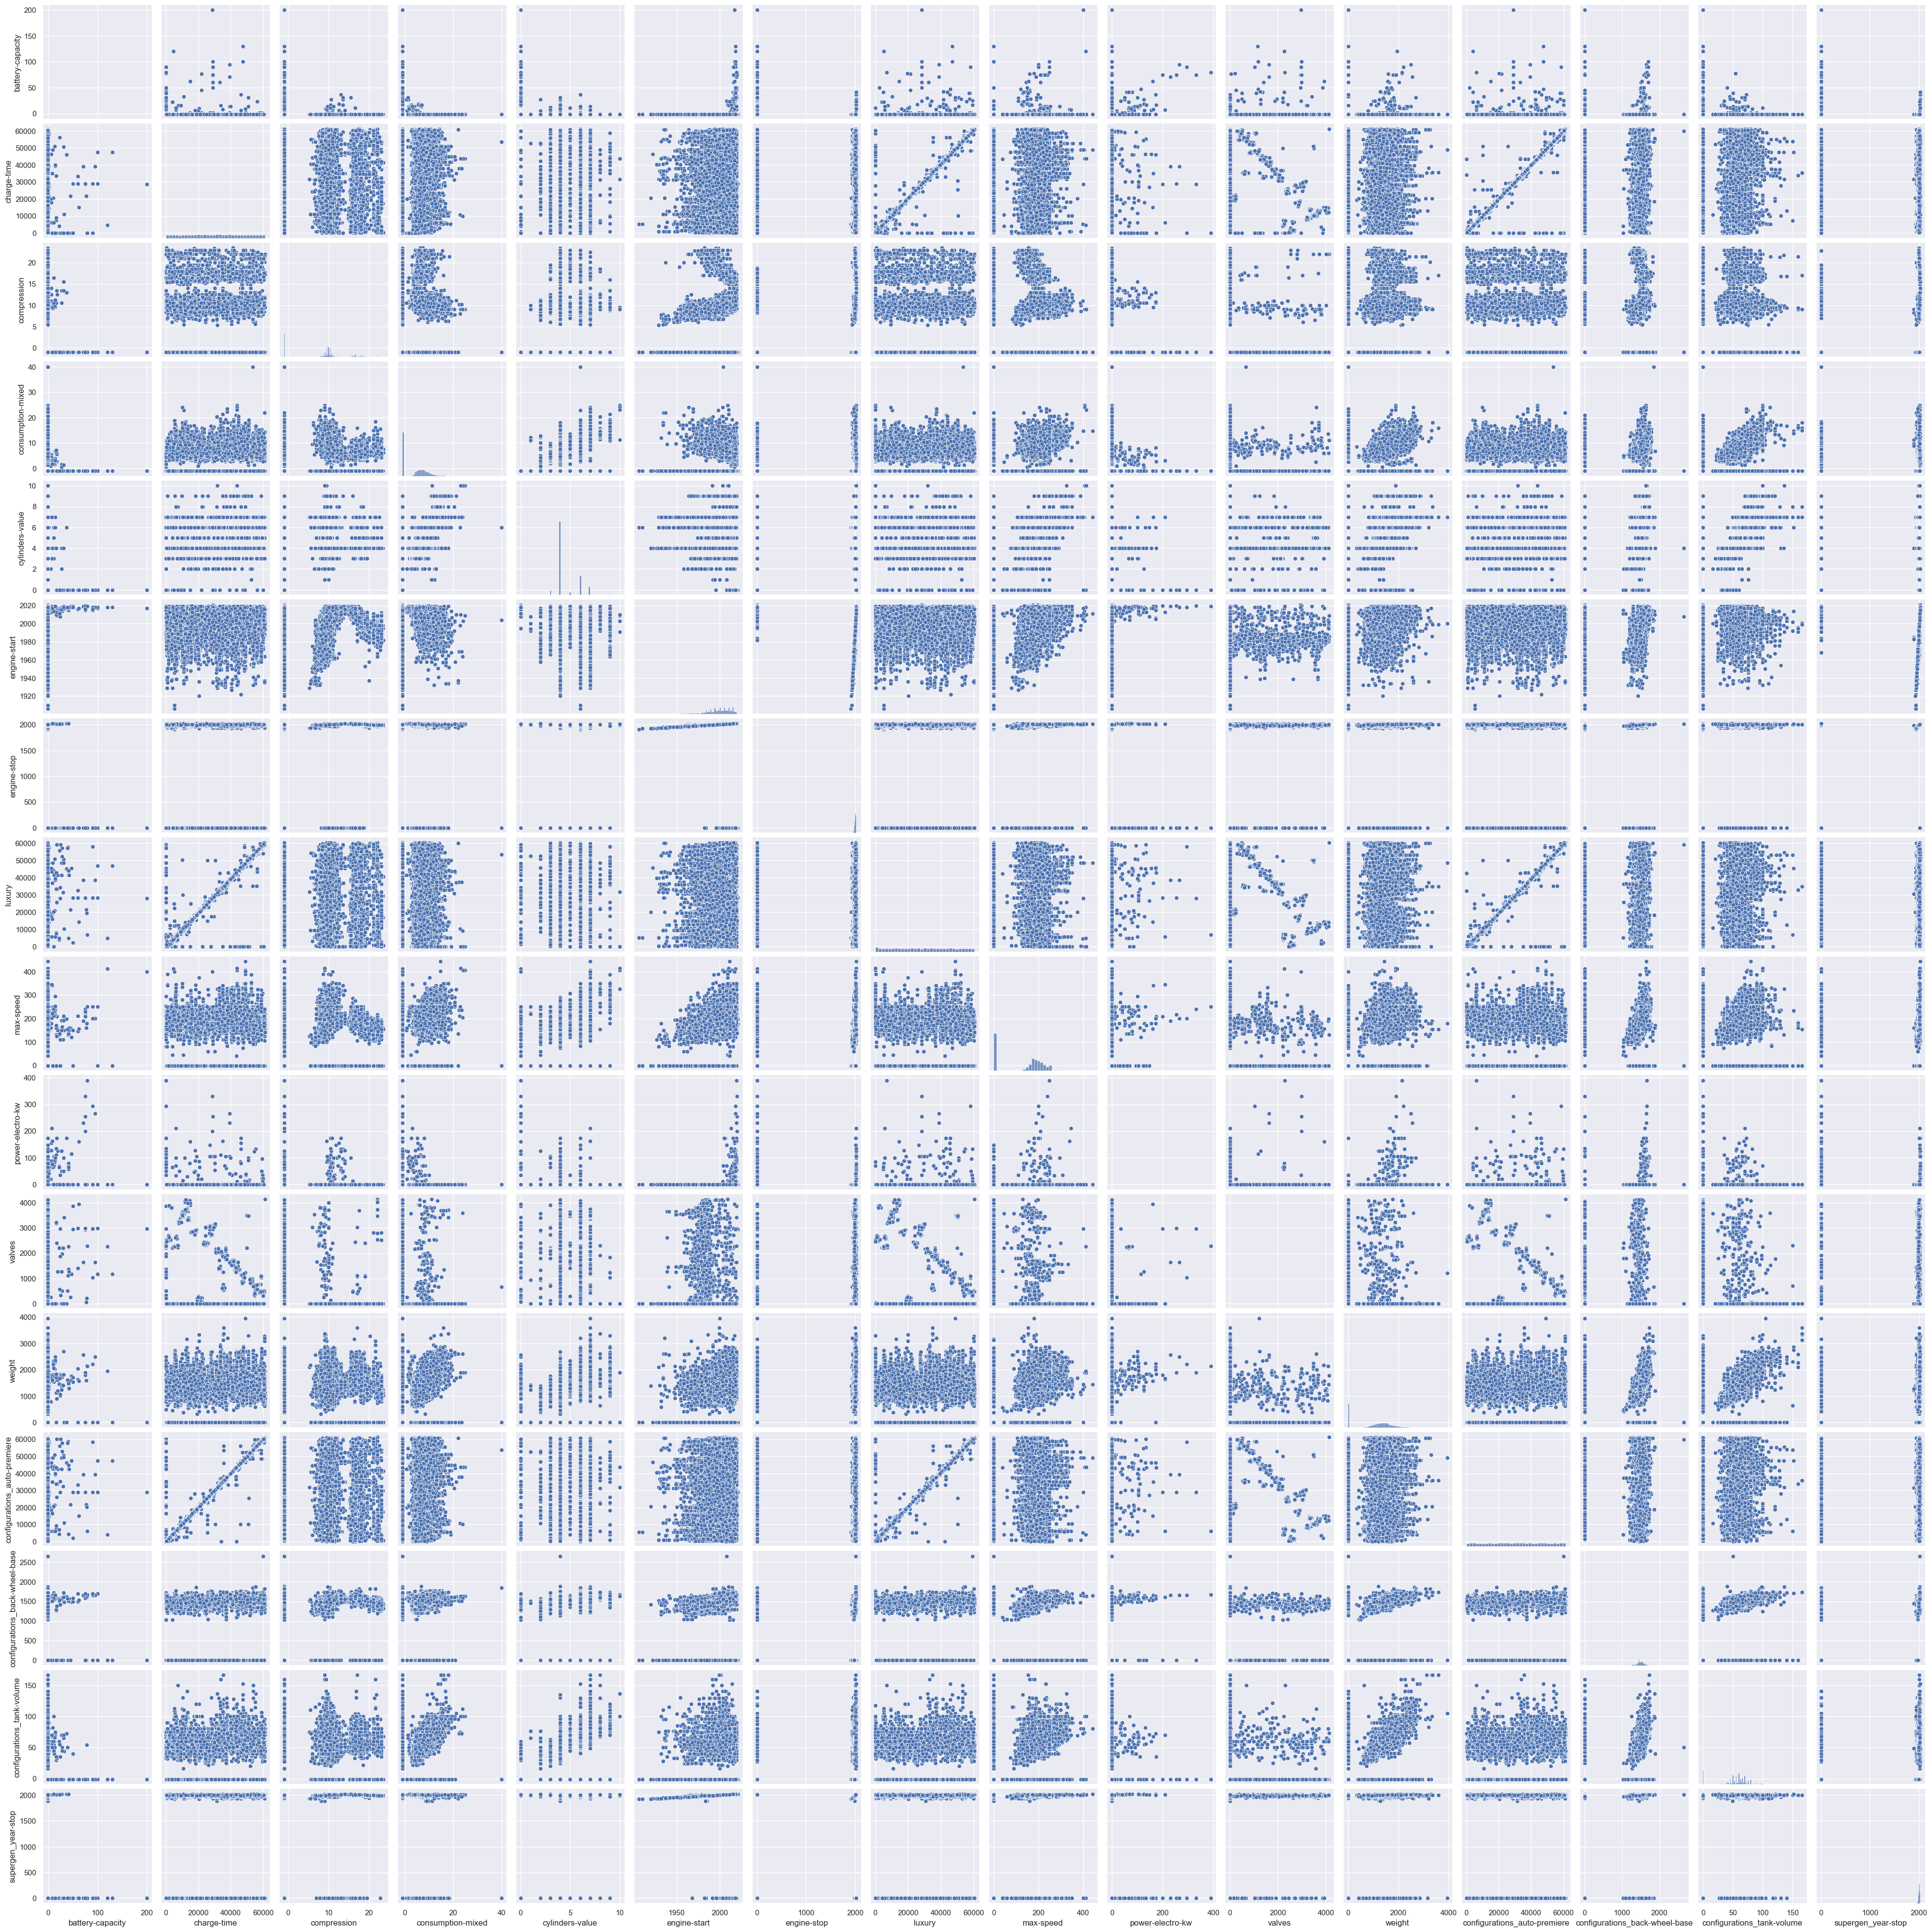

In [7]:
sns.pairplot(train_X[numerical]);

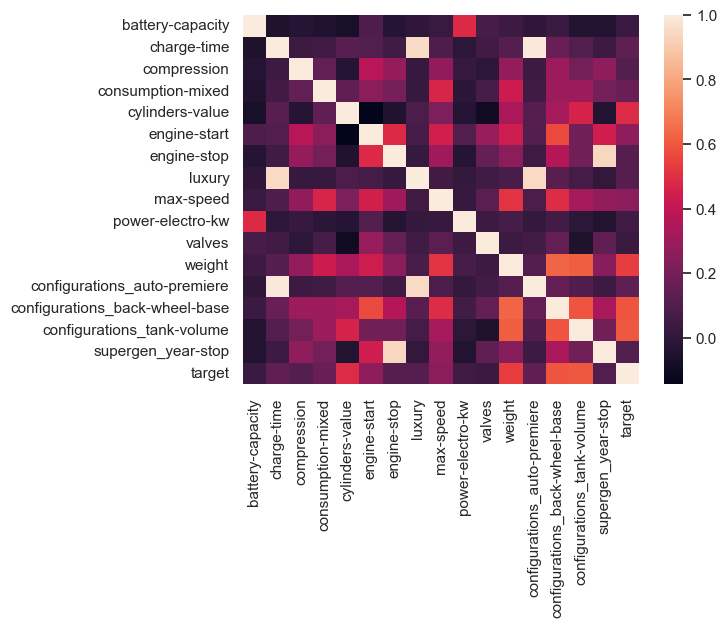

In [8]:
train = train_X
train['target'] = train_y
sns.heatmap(train[numerical + ['target']].corr(method='spearman'));

train = train.drop(["target"], axis=1)

In [9]:
from scipy.stats import pearsonr, spearmanr

r = pearsonr(train['configurations_auto-premiere'], train_y['target'])
print('Pearson correlation:', r[0], 'p-value:', r[1])

Pearson correlation: 0.11003752360955589 p-value: 9.725646829241478e-79


In [10]:
r = pearsonr(train['battery-capacity'], train_y['target'])
print('Pearson correlation:', r[0], 'p-value:', r[1])

Pearson correlation: 0.02366518366709964 p-value: 5.6105473636105006e-05


## F-test

In [11]:
from sklearn.feature_selection import f_regression, SelectKBest

In [12]:
f_statistic, p_values = f_regression(train_X, train_y)

c:\Users\eldo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [13]:
p_values

array([4.14261514e-178, 5.61054736e-005, 2.22583374e-084, 4.29215233e-006,
       5.19880608e-097, 0.00000000e+000, 0.00000000e+000, 3.00761649e-002,
       1.23407205e-153, 1.91780781e-122, 1.08128701e-102, 5.89170255e-038,
       1.18423856e-051, 6.73034264e-090, 6.04804785e-008, 3.29025321e-015,
       3.33873440e-033, 1.45689423e-002, 0.00000000e+000, 9.72564683e-079,
       6.46321123e-022, 5.15233301e-231, 8.63015515e-002, 0.00000000e+000,
       0.00000000e+000, 1.90641086e-122, 7.01981268e-140, 5.09638729e-005,
       4.56879391e-064, 3.51507643e-001, 0.00000000e+000])

In [14]:
sekector = SelectKBest(f_regression, k=20)
sekector.fit_transform(train_X, train_y)

c:\Users\eldo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


array([[ 3.0000e+00,  1.1636e+04, -1.0000e+00, ...,  1.6000e+01,
         0.0000e+00,  2.4300e+03],
       [ 8.0000e+00,  3.1764e+04, -1.0000e+00, ...,  2.3000e+01,
         0.0000e+00,  2.4400e+03],
       [ 8.0000e+00,  2.7730e+03,  6.8000e+00, ...,  1.0000e+01,
         0.0000e+00,  2.6850e+03],
       ...,
       [ 3.0000e+00,  4.8819e+04,  7.6000e+00, ...,  2.6000e+01,
         0.0000e+00,  2.6700e+03],
       [ 1.0000e+01,  9.3460e+03, -1.0000e+00, ...,  1.6000e+01,
         0.0000e+00,  2.5000e+03],
       [ 3.0000e+00,  4.3309e+04, -1.0000e+00, ...,  3.5000e+01,
         0.0000e+00,  2.8800e+03]], shape=(28974, 20))

In [15]:
sekector.get_feature_names_out()

array(['back-suspension', 'charge-time', 'consumption-mixed',
       'cylinders-order', 'cylinders-value', 'engine-start',
       'engine-stop', 'engine-type', 'gear-type', 'luxury', 'max-speed',
       'weight', 'configurations_auto-premiere',
       'configurations_front-brake', 'configurations_seats',
       'configurations_tank-volume', 'supergen_year-stop',
       'models_country-from', 'models_light-and-commercial', 'target'],
      dtype=object)

## Значения Шепли

In [16]:
import shap

In [107]:
df = pd.read_csv("https://raw.githubusercontent.com/katarina74/ml_lessons/main/lesson_2/data/techparams_train.csv")
X = df.drop(["target", "index"], axis=1)
y = df[["target"]]

train_X, test_X, train_y, test_y = train_test_split(X, y, test_size=0.33, random_state=42)

In [18]:
reg = LinearRegression().fit(train_X, train_y)

In [19]:
explainer = shap.Explainer(reg, train_X)
shap_values = explainer(train_X)

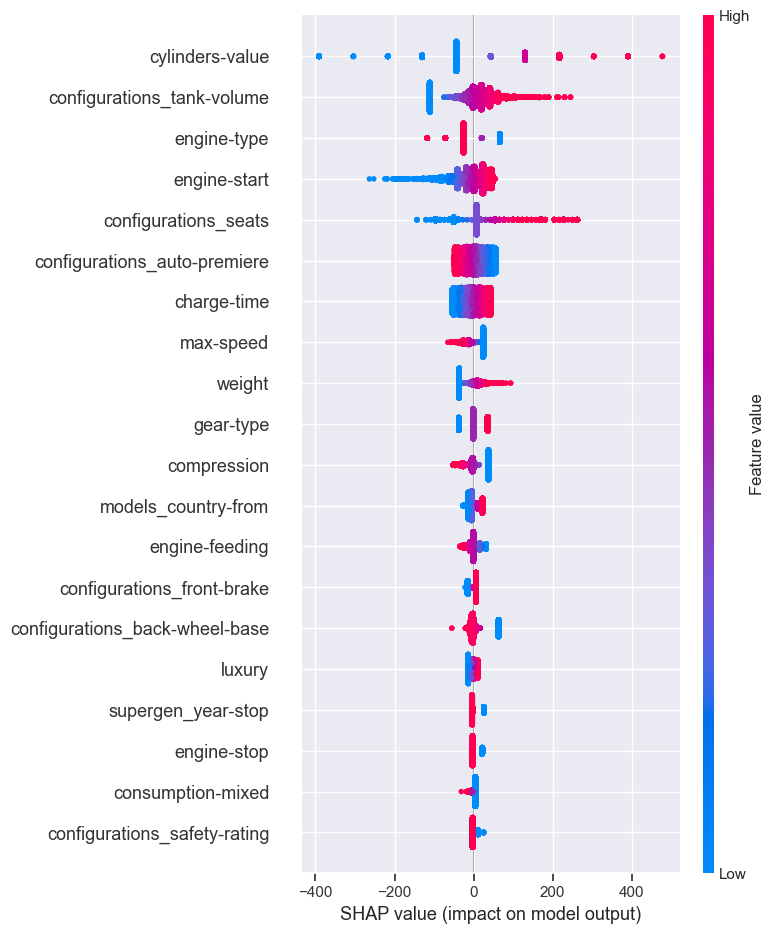

In [20]:
shap.summary_plot(shap_values, train_X)

Для признака cylinders-value наблюдается положительная статистическая зависимость от целевой переменной. Сравните Ваш результат с результатом работы библиотеки shap.

In [137]:
train_cut_X = train_X[train_X.columns[:9]]
test_cut_X = test_X[train_X.columns[:9]]
train_cut_X.columns

Index(['back-suspension', 'battery-capacity', 'charge-time', 'compression',
       'consumption-mixed', 'cylinders-order', 'cylinders-value',
       'engine-feeding', 'engine-start'],
      dtype='str')

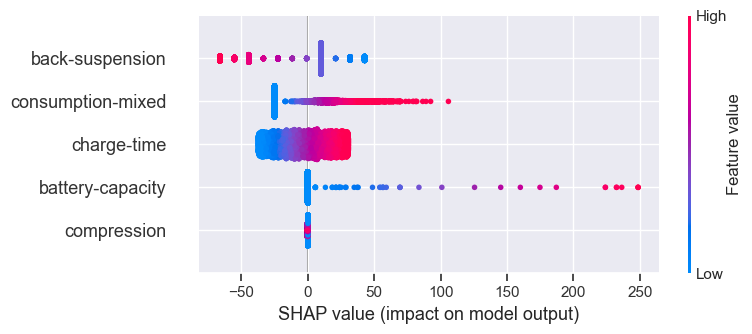

In [22]:
reg = LinearRegression().fit(train_cut_X, train_y)

explainer = shap.Explainer(reg, train_cut_X)
shap_values = explainer(test_cut_X)

shap.summary_plot(shap_values, test_cut_X)

In [23]:
all_features = train_cut_X.columns

In [24]:
i = all_features[0]
N = all_features[1:]

In [25]:
def subsets(S):
    sets = []
    len_S = len( S )
    for i in range( 1 << len_S ):
        subset = [ S[ bit ] for bit in range( len_S ) if i & ( 1 << bit ) ]
        sets.append( subset )
    return sets

{'back-suspension': 555.7988331484174, 'battery-capacity': 167.57287714816536, 'charge-time': 171.8433880499981, 'compression': 31.940719582367898, 'consumption-mixed': 192.48289436178646, 'cylinders-order': 2842.520441936027, 'cylinders-value': 7286.726943106745, 'engine-feeding': 44.092846791487716, 'engine-start': 1765.710697525588}


<Axes: >

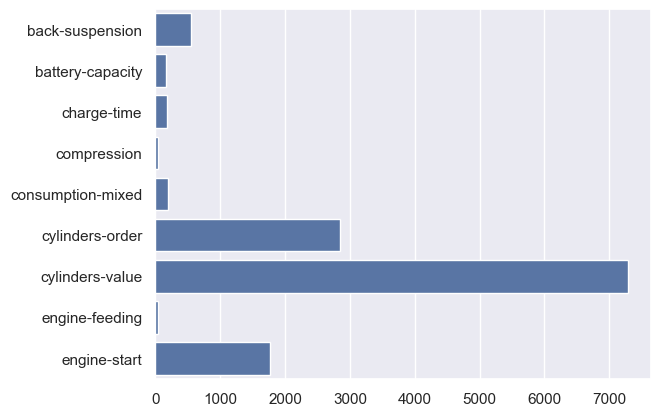

In [139]:
import math
res = []
fi = {}
N_with_i = train_cut_X.columns
for future in N_with_i:
    N_out_i = list(set(N_with_i) - {future})
    for S in subsets(list(N_out_i))[1:]:
        model_with_i = LinearRegression()
        model_out_i = LinearRegression()
        model_out_i.fit(train_cut_X[S], train_y)
        model_with_i.fit(train_cut_X[list(set(S) | {future})], train_y)
        y_pred_with_i = model_with_i.predict(test_cut_X[list(set(S) | {future})])
        y_pred_out_i = model_out_i.predict(test_cut_X[S])
        res.append((math.factorial(len(S))*math.factorial(len(N_with_i)-len(S)-1))/math.factorial(len(N_with_i))*((((y_pred_with_i-y_pred_out_i))**2).mean()))
    fi.update({future:float(np.sum(res))})
    res = []
print(fi)
sns.barplot(x=fi.values(), y=fi.keys())

In [140]:
def shaple_value(X, Y, random_state=14, test_size=0.2):
    def subsets(S):
        sets = []
        len_S = len( S )
        for i in range( 1 << len_S ):
            subset = [ S[ bit ] for bit in range( len_S ) if i & ( 1 << bit ) ]
            sets.append( subset )
        return sets

    train_X, test_X, train_y, test_y = train_test_split(X, Y, test_size=test_size, random_state=random_state)

    res = []
    fi = {}
    N_with_i = train_X.columns
    for future in N_with_i:
        N_out_i = list(set(N_with_i) - {future})
        for S in subsets(list(N_out_i))[1:]:
            model_with_i = LinearRegression()
            model_out_i = LinearRegression()
            model_out_i.fit(train_X[S], train_y)
            model_with_i.fit(train_X[list(set(S) | {future})], train_y)
            y_pred_with_i = model_with_i.predict(test_X[list(set(S) | {future})])
            y_pred_out_i = model_out_i.predict(test_X[S])
            res.append((math.factorial(len(S))*math.factorial(len(N_with_i)-len(S)-1))/math.factorial(len(N_with_i))*((((y_pred_with_i-y_pred_out_i))**2).mean()))
        fi.update({future:float(np.sum(res))})
        res = []
    return fi, sns.barplot(x=fi.values(), y=fi.keys())


In [110]:
X[X.columns[:5]]

,back-suspension,battery-capacity,charge-time,compression,consumption-mixed
0,9,-1.0,36457,9.0,4.3
1,3,-1.0,44872,8.0,-1.0
2,3,-1.0,55927,16.0,4.2
3,0,-1.0,41405,10.3,-1.0
4,8,-1.0,22523,19.0,-1.0
...,...,...,...,...,...
43240,9,-1.0,34558,11.2,6.6
43241,3,-1.0,38268,9.6,5.8
43242,3,-1.0,8958,10.0,9.3
43243,3,-1.0,20293,8.5,-1.0


In [111]:
y[y.columns[:5]]

,target
0,2360
1,3060
2,2648
3,2513
4,2703
...,...
43240,2510
43241,2808
43242,2520
43243,2755


({'back-suspension': 872.759916516215,
  'battery-capacity': 29.586843954291247,
  'charge-time': 364.69783915813576,
  'compression': 5.247954895984468,
  'consumption-mixed': 484.8845322905788},
 <Axes: >)

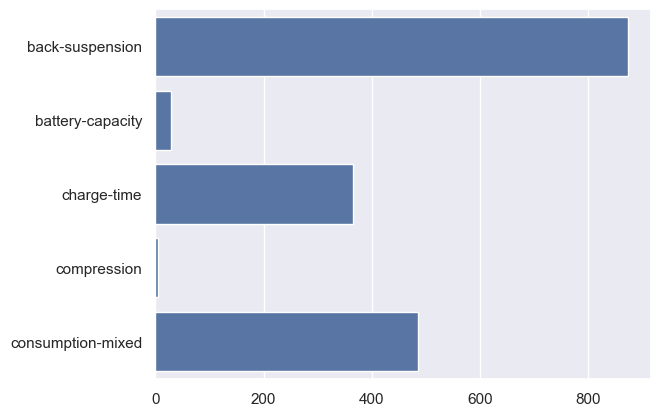

In [141]:
shaple_value(X[X.columns[:5]], y)

In [74]:
N_with_i = train_cut_X.columns
list(set(N_with_i) - {'compression'})

['consumption-mixed', 'charge-time', 'battery-capacity', 'back-suspension']

In [60]:
list(train_cut_X.columns).remove('compression')

In [135]:
s = {1, 2, 3}
s.add(4)
set(['a', 'b', 'c']) | {'d'}

{'a', 'b', 'c', 'd'}

In [125]:
set(['a', 'b', 'c']) + {'k'}

TypeError: unsupported operand type(s) for +: 'set' and 'set'

In [ ]:
N = ['a', 'b', 'c']
N.remove('a')
N
N.append('12')
N

TypeError: list.remove() takes no keyword arguments

In [ ]:
for i in range( )

In [38]:
all_S = subsets(N)[1:]
all_S

[['battery-capacity'],
 ['charge-time'],
 ['battery-capacity', 'charge-time'],
 ['compression'],
 ['battery-capacity', 'compression'],
 ['charge-time', 'compression'],
 ['battery-capacity', 'charge-time', 'compression'],
 ['consumption-mixed'],
 ['battery-capacity', 'consumption-mixed'],
 ['charge-time', 'consumption-mixed'],
 ['battery-capacity', 'charge-time', 'consumption-mixed'],
 ['compression', 'consumption-mixed'],
 ['battery-capacity', 'compression', 'consumption-mixed'],
 ['charge-time', 'compression', 'consumption-mixed'],
 ['battery-capacity', 'charge-time', 'compression', 'consumption-mixed']]

### Задание

Для сокращенных данных (train_cut_X и test_cut_X) реализовать метод отбора важности признаков по Шепли.

## Пермутационная важность

In [27]:
!pip uninstall scikit-learn -y

Found existing installation: scikit-learn 1.8.0
Uninstalling scikit-learn-1.8.0:
  Successfully uninstalled scikit-learn-1.8.0


You can safely remove it manually.


In [28]:
!pip install scikit-learn==1.2.0

     ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
     ---------------------------------------- 0.0/7.2 MB ? eta -:--:--
     - -------------------------------------- 0.3/7.2 MB ? eta -:--:--
     -- ------------------------------------- 0.5/7.2 MB 890.6 kB/s eta 0:00:08
     -- ------------------------------------- 0.5/7.2 MB 890.6 kB/s eta 0:00:08
     -- ------------------------------------- 0.5/7.2 MB 890.6 kB/s eta 0:00:08
     -- ------------------------------------- 0.5/7.2 MB 890.6 kB/s eta 0:00:08
     ----- ---------------------------------- 1.0/7.2 MB 664.6 kB/s eta 0:00:10
     ----- ---------------------------------- 1.0/7.2 MB 664.6 kB/s eta 0:00:10
     ------- -------------------------------- 1.3/7.2 MB 678.9 kB/s eta 0:00:09
     ------- -------------------------------- 1.3/7.2 MB 678.9 kB/s eta 0:00:09
     -------- ------------------------------- 1.6/7.2 MB 662.8 kB/s eta 0:00

  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [32 lines of output]
      Traceback (most recent call last):
        File "C:\Users\eldo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 389, in <module>
          main()
          ~~~~^^
        File "C:\Users\eldo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 373, in main
          json_out["return_val"] = hook(**hook_input["kwargs"])
                                   ~~~~^^^^^^^^^^^^^^^^^^^^^^^^
        File "C:\Users\eldo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_vendor\pyproject_hooks\_in_process\_in_process.py", line 137, in get_requires_for_build_wheel
          backend = _build_backend()
        File "C:\Users\eldo7\AppData\Local\Programs\Python\Python314\Lib\site-packages\pip\_ven

In [34]:
import eli5
from eli5.sklearn import PermutationImportance

In [35]:
reg = LinearRegression().fit(train_X, train_y)

In [36]:
perm = PermutationImportance(reg, random_state=42).fit(test_X, test_y)

In [37]:
eli5.show_weights(perm, feature_names=list(test_X.columns))

Weight,Feature
0.3617 ± 0.0044,cylinders-value
0.1035 ± 0.0039,configurations_tank-volume
0.0959 ± 0.0066,configurations_seats
0.0498 ± 0.0020,engine-type
0.0466 ± 0.0009,engine-start
0.0291 ± 0.0012,configurations_auto-premiere
0.0287 ± 0.0023,charge-time
0.0196 ± 0.0027,compression
0.0193 ± 0.0019,gear-type
0.0165 ± 0.0020,weight


### Задание

Самостоятельно реализовать алгоритм отбора признаков на основе пермутационной важности. Построить гистограмму полученных значений.

In [39]:
import random
train_X[["battery-capacity"]].values

array([[-1.],
       [-1.],
       [-1.],
       ...,
       [-1.],
       [-1.],
       [-1.]], shape=(28974, 1))

In [40]:
lst = train_X.iloc[2].values
lst

array([ 8.000e+00, -1.000e+00,  2.773e+03,  8.800e+00,  6.800e+00,
        0.000e+00,  4.000e+00,  4.000e+00,  2.009e+03,  2.012e+03,
        2.000e+00,  1.000e+00,  2.258e+03,  2.210e+02, -1.000e+00,
        3.000e+00,  2.000e+00,  4.000e+00,  1.373e+03,  2.763e+03,
        1.558e+03,  4.000e+00,  1.000e+00,  1.300e+01,  5.600e+01,
        2.012e+03,  1.000e+01,  3.000e+00,  0.000e+00,  1.000e+00])

In [42]:
np.random.shuffle(lst)
lst

ValueError: array is read-only